# Solving the Poisson equation in a charge-free box 

**A simple Python tutorial on electrostatic simulations using QTCAD®**

## Introduction

### 1. Goal

With this tutorial, we will discuss a bit further the [Poisson equation 🔗](https://en.wikipedia.org/wiki/Poisson%27s_equation): its physical meaning, and how boundary conditions determine the electrostatic potential inside a physical region.

We will then solve the simple case of a charge-free Poisson problem (which is also known as the [Laplace problem 🔗](https://en.wikipedia.org/wiki/Laplace%27s_equation)) inside a rectangular box using QTCAD®.
The focus will be on a qualitative understanding of the physics, rather than discussing the theory and numerical details at length.


This tutorial only assumes a basic familiarity with electric fields and potentials.
No prior experience with QTCAD® is required.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

Some freely available references that overview the above topics are
- OpenStax’s notes (introductory level):
  - [Electric Field - Concept of a Field Revisited 🔗](https://phys.libretexts.org/Bookshelves/College_Physics/College_Physics_1e_(OpenStax)/18%3A_Electric_Charge_and_Electric_Field/18.04%3A_Electric_Field-_Concept_of_a_Field_Revisited)
  - [Electric Potential Energy- Potential Difference 🔗](https://phys.libretexts.org/Bookshelves/College_Physics/College_Physics_1e_(OpenStax)/19%3A_Electric_Potential_and_Electric_Field/19.01%3A_Electric_Potential_Energy-_Potential_Difference)
- S. W. Ellingson’s notes (intermediate, university level):
  - [Electric Field as the Gradient of Potential 🔗](https://phys.libretexts.org/Bookshelves/Electricity_and_Magnetism/Electromagnetics_I_(Ellingson)/05%3A_Electrostatics/5.14%3A_Electric_Field_as_the_Gradient_of_Potential)
  - [Poisson’s and Laplace’s Equations 🔗](https://phys.libretexts.org/Bookshelves/Electricity_and_Magnetism/Electromagnetics_I_(Ellingson)/05%3A_Electrostatics/5.15%3A_Poissons_and_Laplaces_Equations)

</div>

### 2. Electrostatic potential and electric field

In electrostatics, the **electric field** $\vec{E}$ is a [vector quantity 🔗](https://phys.libretexts.org/Bookshelves/Electricity_and_Magnetism/Electromagnetics_I_(Ellingson)/04%3A_Vector_Analysis/4.01%3A_Vector_Arithmetic) that is related to the **electrostatic potential** $\varphi$ by

$\vec{E}(\vec{r}) = - \nabla \varphi(\vec{r}),$

where $\nabla$ is the [gradient operator 🔗](https://phys.libretexts.org/Bookshelves/Electricity_and_Magnetism/Electromagnetics_I_(Ellingson)/04%3A_Vector_Analysis/4.05%3A_Gradient).

This expression tells us that:

- The electric field points in the direction of decreasing potential (illustrated by [this figure 🔗](https://en.wikipedia.org/wiki/Electric_potential#/media/File:VFPt_metal_balls_largesmall_potential+contour.svg));
- Electrostatic fields are conservative, that is, the work done to move a charge between two points in space is independent of the path taken, meaning no energy is lost in the process.

### 3. Gauss’s law and the Poisson Equation

The electric field resulting from a distribution of electric charges with (charge) density $\rho$ is given by [Gauss’s law 🔗](https://en.wikipedia.org/wiki/Gauss%27s_law).
It is given, in its differential form, by

$\nabla \cdot E(\vec{r}) = \dfrac{\rho(\vec{r})}{\epsilon}$,

where $\nabla \cdot$ is the [divergence 🔗](https://phys.libretexts.org/Bookshelves/Electricity_and_Magnetism/Electromagnetics_I_(Ellingson)/04%3A_Vector_Analysis/4.06%3A_Divergence) of the electric field $\vec{E}$.

By replacing $\vec{E}$ by the relation between electrostatic potential and electric field, $E = - \nabla \varphi$, we arrive at the **Poisson equation**:

$\nabla \cdot (- \nabla \varphi) = \dfrac{\rho}{\epsilon}$.

Since $\nabla \cdot \nabla = \nabla^2$, this equation can also be represented as:

$\nabla^2 \varphi(\vec{r}) = - \dfrac{\rho(\vec{r})}{\epsilon}$,

where
- $\varphi$ is the electrostatic potential, given in V (volts);
- $\rho$: charge density, given in C/m³ (C: coulombs; m: metres);
- $\epsilon$ is the permittivity of the material.

That is, Poisson’s equation allows us to compute the electric potential $\varphi$ from a given distribution of charges $\rho$.

### 4. Boundary conditions

To uniquely solve Poisson’s equation, appropriate boundary conditions must be specified.
**Boundary conditions** define how the electrostatic potential $\varphi$ behaves at the edges of the simulation domain and are essential for obtaining a physically meaningful solution.
That is, they are constraints on the behaviour of $\varphi$.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

The use of boundary conditions arise from the theory of differential equations. For more introductory information, please refer to N. Walet’s chapter [‘Boundary and Initial Conditions’ 🔗](https://math.libretexts.org/Bookshelves/Differential_Equations/Partial_Differential_Equations_(Walet)/03%3A_Boundary_and_Initial_Conditions).

</div>

#### 4.1 Dirichlet boundary conditions (fixed potential)

Relevant for us is the so-called ‘Dirichlet boundary condition’, in which the values of the solution along a boundary of the simulation domain are fixed.
Here, a ‘boundary’ represents a subset of position vectors $\vec{r} = (x, y, z)$, usually on the interfaces between different components of a device.

We use Dirichlet boundary conditions to specify the value of the electrostatic potential $\varphi$ directly on a boundary:

$\varphi(x,y,z) = V_0$ for $x$, $y$ and $z$ along a given boundary.

Physically, this type of boundary condition represents an ideal metallic contact held at a fixed voltage.
One assumes the potential to be enforced by an external source and that it does not change during the solution process.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

The Poisson solver⁽¹⁾ in QTCAD® solves Poisson’s equation subject to the boundary conditions specified by the user. QTCAD® supports [multiple types of boundary conditions 🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/poisson/#boundary-conditions), allowing accurate electrostatic modelling under a wide range of conditions, including cryogenic temperatures.

In this tutorial, we restrict ourselves to Dirichlet boundary conditions in order to clearly demonstrate the fundamental behaviour of the Poisson equation in a simple geometry.
A detailed discussion of the additional boundary condition types available in QTCAD® will be presented in later sessions.

---

<small>
    
(1) We call a ‘solver’ the component of QTCAD® responsible for different simulations. For instance, to solve the Poisson equation, we use one of QTCAD®’s Poisson solvers.
More information on it can be found on QTCAD®’s documentation: [QTCAD®: Theory — Finite elements – 1. Poisson solvers 🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/poisson/).
  
</small>

</div>

## Analytical calculation of the potential inside a grounded box with a biased lid

In this tutorial, we consider a cubical cube of side length $a=10~\text{nm}$ consisting of five conducting metal plates that are welded together and held at ground potential, $\varphi_\text{ground} = 0~\text{V}$.
These plates, lightly coloured in the figure below, form the bottom and the four side walls of the box.

<div><img src="figures/fig_grounded_box.png" width="500px"/></div>

The sixth plate (the top surface, darkly coloured in the figure above) is a separate conducting plate that is electrically insulated from the others and held at a constant potential $\varphi_0=1V$.

The inside of the box is empty, there are no charged particles freely roaming inside it.

Our **goal** is to determine the electrostatic potential $\varphi(x,y,z)$ inside the box.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

This problem is adapted from Problem 3.16 of Griffiths, D. J. [‘Introduction to electrodynamics’ 🔗](https://openlibrary.org/books/OL25840902M/Introduction_to_electrodynamics). (Pearson, 2013). ISBN 978-0-321-85656-2, p. 141.

</div>

### 5.1 Geometry

In this problem, the spatial variables are constrained to values inside the box.
That is, we define a cubic domain where

$0<x<a, \hspace{2em} 0<y<a \hspace{2em}\text{and}\hspace{2em} 0<z<a$.

### 5.2 Governing equation

The equation we must solve to compute $\varphi$ is the Poisson equation.

Since there is no free charges inside the box, the charge density is zero everywhere:

$\rho(x,y,z) = 0$

and the Poisson equation therefore simplifies to

$\nabla^2 \varphi = 0$.

### 5.3 Boundary conditions

As described in the problem statement, the conducting plates are held at fixed potentials.

Hence, the boundary conditions here are the following in units of volts (V):

- Grounded plates (walls and bottom surfaces) at $\varphi_\text{ground}$:
  - $\varphi (0,y,z) = \varphi(a,y,z) = 0$
  - $\varphi (x,0,z) = \varphi(x,a,z) = 0$
  - $\varphi (x,y,0) = 0$ 
- Top plate at the fixed potential $\varphi_0$:
  - $\varphi (x,y,a) = 1$

These Dirichlet boundary conditions uniquely determine the solution inside the domain.

### 5.4 Analytical solution

This is a simple problem that can be solved analytically using standard techniques. In this case, the electrostatic potential inside the grounded cubical cube with a biased top plate can be solved using separation of variables.

The solution of Poisson's equation, subject to the Dirichlet boundary conditions described above, is a series given by

$\varphi(x,y,z) = \displaystyle \dfrac{16 \varphi_0}{\pi^2} \sum_{n=1,3,5,\dots} \, \sum_{m=1,3,5,\dots} \dfrac{1}{nm} \sin\left(\dfrac{n\pi x}{a}\right) \sin\left(\dfrac{m \pi y}{a}\right) \dfrac{\sinh\!\left(\pi \sqrt{n^2 + m^2} z/a\right)}{\sinh\!\left(\pi \sqrt{n^2 + m^2}\right)}$.

Here,
- $a$ is the side length of the cube, $a = 10~\text{nm}$;
- $\varphi_0$ is the potential of the top plate, $\varphi_0 = 1~\text{V}$;
- The sums run over all odd integers $n,m = 1,3,5,\dots.

#### Value of the potential at the centre of the cube

Going a bit further, we can also compute the potential at the centre of the cube, where $x=y=z=a/2$, from the above series.

It evaluates to:

$\varphi\left(x=\dfrac{a}{2},y=\dfrac{a}{2},z=\dfrac{a}{2}\right) = \dfrac{\varphi_0}{6}$.

## 6. Numerical simulation of the potential inside a grounded box with a biased lid using QTCAD®

Having shown the analytical solution to the problem of a charge-free box, let us solve it numerically using QTCAD®.

This will serve as a warm-up for the other tutorials, in which we will tackle more elaborate problems in the context of spin-qubit devices.

Furthermore, a basic workflow of QTCAD® simulations usually comprise the following steps in a Python script:
1. Importing or defining a device’s design and generating a mesh following the device’s geometry;
2. Setting up of the appropriate QTCAD® solver and running the simulation;
3. Analysing the simulation results using post-processing features.

More details about the QTCAD® simulation workflow can be found in [Getting Started: 2. Workflow for QTCAD simulations 🔗](https://docs.nanoacademic.com/qtcad/getting_started/workflow/) (20–30 minute read).

### 6.1 Modelling the device using QTCAD® and generating the mesh

Every QTCAD® simulation requires the geometry of the device to be simulated to either be imported or created using QTCAD®.
Also, for finite-element simulations, a mesh associated with that geometry should be generated.

Furthermore, QTCAD® provides [Builder 🔗](https://docs.nanoacademic.com/qtcad/builder/), a tool designed to create geometries of different types of devices and generate their mesh.

In our example, we are solving a simple box-shaped problem.
Hence, we will use QTCAD® Builder to construct a box with a sides of length $a=10~\text{nm}$.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

QTCAD® Builder can handle much more complex geometries and meshes.
We will explore more elaborate designs in the coming sessions.

</div>

#### 6.1.1 Design

First, let us import the necessary modules and packages from QTCAD®, including Builder.

In [1]:
# Imports.
from qtcad.builder import Builder
from qtcad.builder import Mask, Polygon, MeshAlgorithm3D
from pathlib import Path

# Set up directories.
script_dir = Path("__file__").parent
mesh_dir = script_dir / "meshes"
output_dir = script_dir / "output"
mesh_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)
# Set up paths.
mesh_filepath = mesh_dir / "box.msh"

Next, let us define a box to be added to the ‘mask’ and then create the 3D object (the ‘device’).
We also show the geometry of the resulting device.

The design process with QTCAD® Builder requires a ‘mask’⁽²⁾, which serves as a workspace where two-dimensional geometries can be placed.
You can consider it to be a canvas for arranging the shapes that will make up the quantum device.

QTCAD® Builder is designed to create realistic semiconductor devices and therefore follows the same design workflow used in semiconductor fabrication. We begin by placing structures on a mask to define the device layout; this layout is then used to generate a three-dimensional device model, which is subsequently converted into a mesh for simulation. This approach ensures that the simulated devices faithfully reflect actual fabrication processes.

In what follows, we compose several methods of the `Builder` class.
The ones used are listed below, together with a brief description and URLs to their entries in the QTCAD© documentation:
- `add_mask`
  - Add a mask. The newly added mask becomes the current mask and all shapes in it are selected.
  - https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.add_mask
- `use_shape`
  - Select shapes in the current mask that will be used for all following operations.
  - https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.use_shape
- `set_mesh_size`
  - Set the local mesh size for elements added after this point.
  - https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.set_mesh_size
- `extrude`
  - Create a solid extrusion of a given height of a plane shape.
  - https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.extrude
- `view`
  - View the current model (that is, the design/device) using the graphical user interface of [Gmsh 🔗](https://gmsh.info/), which is automatically installed together with QTCAD®.
  - https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.view


---

<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a new window will pop up with the device geometry displayed in Gmsh.
You can freely pan, rotate and zoom.

</div>

<small>
   
(2) The term ‘mask’ comes from the photolithography process used in semiconductor device fabrication.

</small>

In [2]:
# Define a simple box of side length `a`.
# The units of `a` will be defined later.
a = 10
box = Polygon.box(width=a, height=a, name="box").centered()
# Specify the characteristic length for meshing.
# This parameter determines the size of the mesh elements.
# Adjusting it refines or coarsens the mesh globally, controlling the approximate spacing between adjacent mesh nodes.
char_len = 0.5

# Create a mask with the box.
mask = Mask("my_mask")
mask.add_shape(box)

# Create the 3D device by adding the mask and extruding the box region by `a`.
builder = (
    Builder()
    .add_mask(mask)
    .use_shape("box")
    .set_mesh_size(char_len)
    .extrude(a)
    .view(
        volume_labels=True,
        surfaces=True,
        angles=(-45, 0, 45),
        save=str(output_dir / "unrotated_model.svg"),
        font_size=20,
        zoom=0.7,
    )
)


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.1.3                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

[10:08:37] INFO     Extruding shape 0 from mask 'my_mask' with name 'box' by 10 at z=0              ]8;id=321388;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=626273;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1359\1359]8;;\

[10:08:39] INFO     Creating new physical group with name 'box_bottom'                              ]8;id=204315;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=999189;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Creating new physical group with name 'box_side'                                ]8;id=433326;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=347305;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Creating new physical group with name 'box_top'                                 ]8;id=283965;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=764507;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Creating new physical group with name 'box'                                     ]8;id=451322;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=254518;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1254\1254]8;;\

           INFO     Setting z-coordinate to 10                                                       ]8;id=368819;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=258527;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#418\418]8;;\

[10:08:40] INFO     Saving C:\Proyecto_QTCAD\output\unrotated_model.svg                              ]8;id=922176;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=359442;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#885\885]8;;\



Waiting for Gmsh viewer to be closed...


Note that, by default, the `extrude` command extends a shape along the $z$-axis.

Also, the resulting volume and surfaces are automatically named based on the original shape.

For instance, in the present case, the shape is named `box` and we will have:
- Volume: "box";
- Bottom surface: "box_bottom";
- Top surface: "box_top";
- Side surfaces: "box_side".

Of course, in other cases, `box` will be replaced by the appropriate name of the shape.

#### 6.1.2 Mesh

Now, let us generate the mesh from the geometry of the device.
When creating a device using QTCAD® Builder, we only need to call the method `mesh` with the appropriate parameters.

For more information on this method, please refer to its documentation: https://docs.nanoacademic.com/qtcad/API_reference/qtcad.builder/#qtcad.builder.Builder.view.

In [3]:
# Generate the mesh.
builder.mesh(3, algorithm3d=MeshAlgorithm3D.Delaunay, show_gmsh_output=True).write(
    mesh_filepath
)

[10:08:47] INFO     Preparing to mesh                                                                ]8;id=659963;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=626021;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#663\663]8;;\

           INFO     Detecting appropriate random factor                                             ]8;id=103283;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=119350;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1954\1954]8;;\

           INFO     Random factor is now appropriate                                                ]8;id=502249;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=271364;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#1972\1972]8;;\

           INFO     Meshing                                                                          ]8;id=290662;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=755444;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#675\675]8;;\

[10:09:05] INFO     Checking mesh conformity                                                        ]8;id=737356;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=311345;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#2003\2003]8;;\

           INFO     Writing C:\Users\aefra\AppData\Local\Temp\tmpeqk_vxj7\mesh.msh                   ]8;id=443311;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=163469;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#730\730]8;;\

[10:09:08] INFO     Checking connectivity                                                           ]8;id=865469;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=828732;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#2023\2023]8;;\

nodes:   0%|          | 0/7598 [00:00<?, ?it/s]

           INFO     Writing C:\Proyecto_QTCAD\meshes\box.msh                                         ]8;id=773773;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py\builder.py]8;;\:]8;id=470262;file://c:\Users\aefra\anaconda3\envs\qtcad\Lib\site-packages\qtcad\builder\core\builder.py#730\730]8;;\

### 6.2 Simulation with QTCAD®

Now that the device was designed and its mesh was generated, we can start the QTCAD® simulation step.

Typically, we follow these steps:

- 6.2.1 **Importing the mesh**  
  - The mesh can be created with Builder (as in this tutorial) or imported from an external source.
- 6.2.2 **Setting up the device**  
  - We associated different regions to specific materials and we define the boundary conditions for the simulation.
- 6.2.3 **Running the simulation**  
  - Run the solver to compute the desired quantities.
- 6.2.4 **Analysing the results**
  - Extract and analyse the results from the simulation.

Let us proceed by importing the necessary classes and modules from QTCAD®.

In [4]:
# Import NumPy for numerical operations.
import numpy as np

# Import QTCAD®’s base classes `Mesh3D` and `Device`.
from qtcad.device import Mesh3D as Mesh
from qtcad.device import Device

# Import QTCAD®’s libraries `materials` and `constants` needed to assign materials to the device’s regions.
from qtcad.device import materials as mt
from qtcad.device import constants as ct

# Import QTCAD®’s Poisson solver and the module that allow us to set its parameters.
from qtcad.device.poisson_linear import Solver as PoissonSolver
from qtcad.device.poisson_linear import SolverParams as PoissonSolverParams

# Import QTCAD®’s analysis class to visualize the simulation results.
from qtcad.device import analysis as an

Also, let us specify the scaling factor to correctly assign the unit of length in our problem.

That is, let us define the units of `a`. Since $a = 10$ nanometers, the factor should be $10^{-9}$.

In [5]:
scaling_factor = 1e-9

#### 6.2.1 Importing the mesh

Let us import the mesh generated with Builder above and visualize it with the method `show` (https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.show).

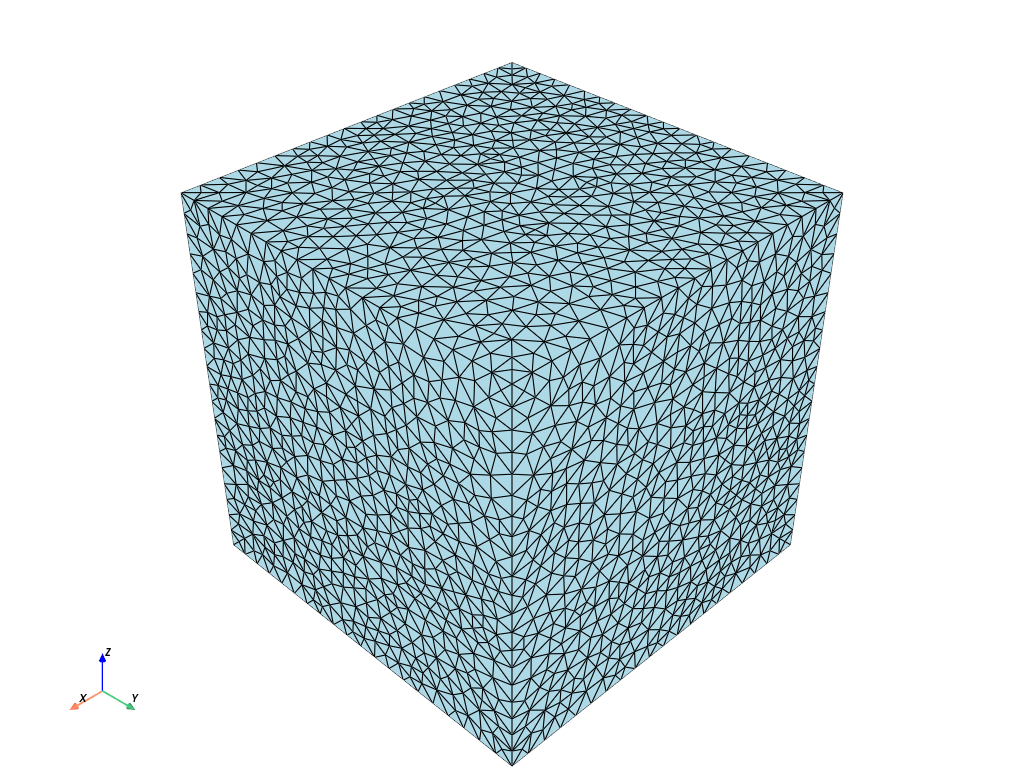

In [6]:
mesh = Mesh(scaling_factor=scaling_factor, filename=mesh_filepath)
mesh.show()

#### 6.2.2 Creating the device

Let us proceed by constructing (instantiating, in proper terms) the `Device` object for the QTCAD® simulation.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

A `Device` instance is the central element of any QTCAD® simulation: it holds *all* the physical information about the simulation. The complete documentation on it can be found in https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.

</div>

To define the device, we need to specify the mesh as its input.

Also, the `conf_carriers` parameter of `Device` specifies the type of charge carriers to consider in the simulation.
Here, we are considering negatively charged particles (electrons), so `conf_carriers` should be set to `"e"`.

In [7]:
dvc = Device(mesh, conf_carriers="e")

Then, let us set the temperature to $1~\text{K}$.

To define the temperature is critical for quantum simulations to minimize thermal effects, but it does not affect the problem in this specific example.

In [8]:
dvc.set_temperature(1)

Now, let us assign the material properties to the 3D volume of our device. Let us consider the box to be ‘filled’ with vaccum.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

QTCAD® is primarily designed for semiconductor device simulations and the material properties are crucial for accurate results.

In this example, we assign ‘vacuum’ to the entire box for simplicity, but in a real quantum-device simulations, you would typically assign semiconductor materials having the desired parameters for your purposes.

</div>

In [9]:
dvc.new_region("box", material=mt.vacuum)

Next, let us both assign the boundary conditions to the difference surfaces of our device and define the charge density.

Remember that in our case, the charge density is zero everywhere inside the box, as there no free charge carriers in our case.

In [10]:
# Assign the boundary conditions
# - Set the potential to 0 V at the bottom surface.
dvc.new_dirichlet_bnd("box_bottom", 0)
# - Set the potential to 0 V at the side surfaces.
dvc.new_dirichlet_bnd("box_side", 0)
# - Set the potential to 1 V at the top surface.
dvc.new_dirichlet_bnd("box_top", 1)

# Set the charge density to zero everywhere.
def zero_charge_density(x, y, z):
    return 0.0

dvc.set_charge_density(zero_charge_density)

Lastly, once again with the `show` method, let us visualize the device in 3D.
The assigned materials and boundary conditions will be labelled accordingly.


<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a Jupyter widget will appear below it showing the device.
You can freely pan, rotate and zoom, as well as selectively show the different surfaces that make up the cube.

</div>

In [11]:
dvc.show()

#### 6.2.3 Running the simulation

We can now set up the Poisson solver and solve the Poisson equation inside the device.

We start by initializing the object that will store the Poisson solver’s parameters and then customizing some of its settings.

All possible parameters are described at https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.poisson_linear/#qtcad.device.poisson_linear.SolverParams.

In [12]:
# Initialize solver parameters.
poisson_params = PoissonSolverParams()

# Define solver parameters.
# - Set the solver tolerance.
poisson_params.tol = 1e-6
# - Set the maximum number of iterations.
poisson_params.maxiter = 1000

Then, we can create (instantiate) the Poisson solver with the device and solver parameters defined in the previous steps.

In [13]:
poisson_solver = PoissonSolver(dvc, poisson_params)

Lastly, we call the `solve` method to solve the Poisson equation and obtain the electrostatic potential distribution in our device.

In [14]:
poisson_solver.solve()

--------------------------------------------------------------------------------
Solving the linear Poisson equation with the boundary conditions displayed below.
--------------------------------------------------------------------------------
Boundary label                              Type            Applied potential (V)
--------------------------------------------------------------------------------
box_bottom                                  dirichlet       0.000000000000      
box_side                                    dirichlet       0.000000000000      
box_top                                     dirichlet       1.000000000000      
--------------------------------------------------------------------------------


#### 6.2.4 Analysing the results

After the simulation finishes, we can continue to the analysis of its results.

##### **Slices**

We can, for instance, visualize the electric potential $\varphi$ we just computed by plotting slices of its intensity in 2D projections.

To that end, we use the module `plot_slices` (https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.analysis/#qtcad.device.analysis.plot_slices).

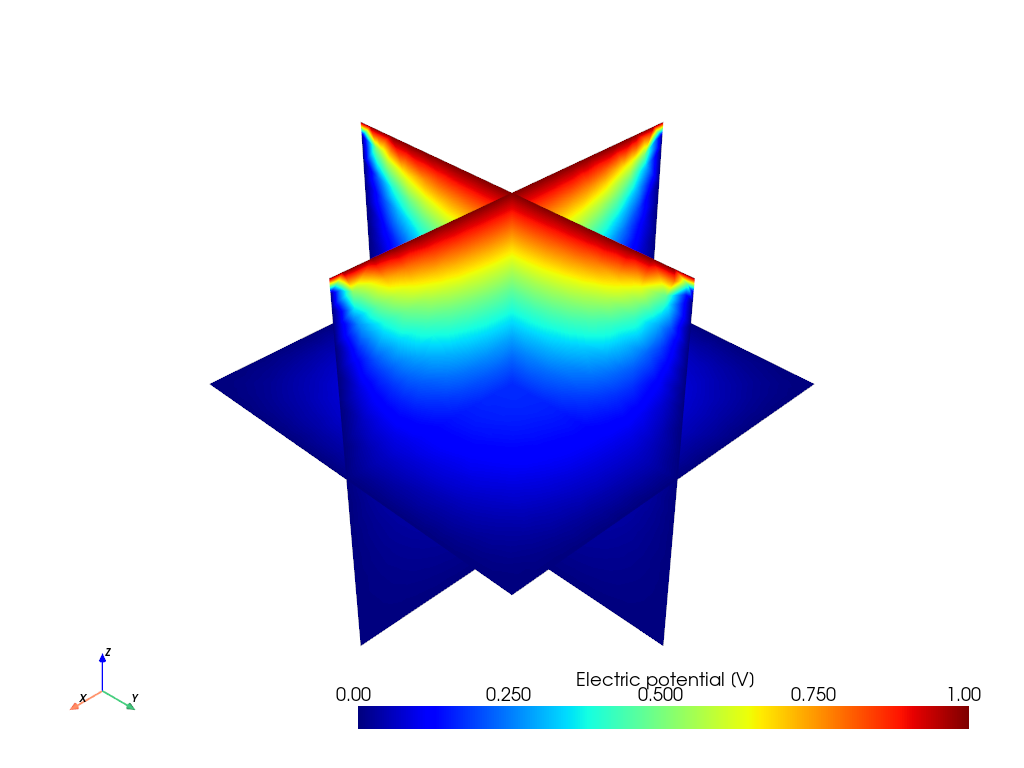

In [15]:
an.plot_slices(mesh, dvc.phi, title="Electric potential [V]")

##### **Line cuts**

Similarly, we can plot a 1D projection of $\varphi$ using the `plot_linecut` method: https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.analysis/#qtcad.device.analysis.plot_linecut.
With it, we can see how $\varphi$ varies along a defined line (or path) through the device.

We pass to it two 3-tuples defining the first and last point along the linecut.

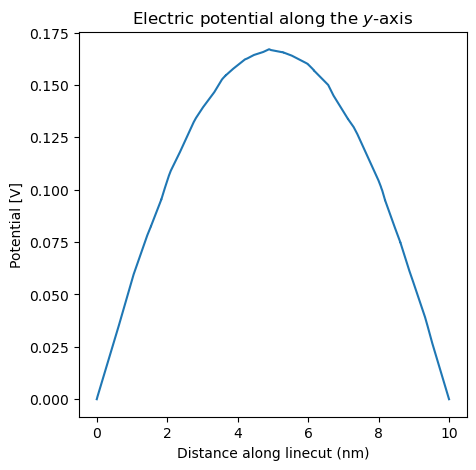

In [16]:
an.plot_linecut(
    mesh,
    dvc.phi,
    # The x, y and z coordinates of the first point along the linecut.
    begin=(0, -5e-9, 5e-9),
    # The x, y and z coordinates of the last point along the linecut.
    end=(0, 5e-9, 5e-9),
    title="Electric potential along the $y$-axis",
    ylabel="Potential [V]",
)

##### **Single 2D slice**

We can also plot a single 2D projection of $\varphi$ as an intensity plot using the `plot_slice` method: https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.analysis/#qtcad.device.analysis.plot_slice.

We pass to it a 3-tuple defining the normal vector for the slice and a 3-tuple defining the origin of (where to) slice.

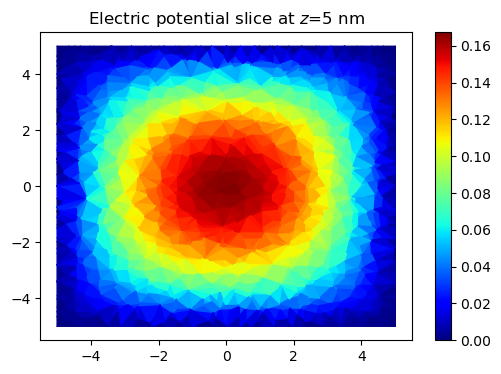

In [17]:
an.plot_slice(
    mesh,
    dvc.phi,
    # The normal vector, a 3-tuple, for the slice.
    normal=(0, 0, 1),
    # The 3-tuple defining the origin for the slice.
    origin=(0, 0, 5e-9),
    title="Electric potential slice at $z$=5 nm",
)

##### **Value of the potential at the centre of the cube**

As in the case we solved analytically before, let us find the value of the electric potential $\varphi$ at the centre of the cube and compare it with the exact theoretical result.

To accomplish that, we will use the method `point_eval`, https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.analysis/#qtcad.device.analysis.point_eval.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

Note that the centre point in our device is at $(x,y,z)=(0,0,5~\text{nm})$

</div>

In [18]:
# Define the 3-tuple with the coordinates of the point of interest.
centre_point = (0, 0, 5e-9)

# Extract the value at the desired point.
V_centre = an.point_eval(mesh, dvc.phi, centre_point)[0]

print(
    f"The electric potential φ at the centre point {centre_point} is {V_centre:.6f} V."
)
print(
    f"The theoretical value of φ computed analytically is ϕ₀/6 = {1/6:.6f} V."
)

The electric potential φ at the centre point (0, 0, 5e-09) is 0.166463 V.
The theoretical value of φ computed analytically is ϕ₀/6 = 0.166667 V.


It is clear that the potential $\varphi$  at the centre of the cube computed numerically using QTCAD® is in full agreement with the theoretical value.

### Conclusion:

In this example, we introduced a simple problem with a straightforward geometry and demonstrated how to use QTCAD® to compute the electrostatic potential. This example illustrates the core steps involved in many QTCAD® simulations, which include:

- Creating a geometry and mesh using QTCAD® Builder.
- Defining the device and its relevant parameters, such as the material assigned to each region of the geometry and the boundary conditions for the Poisson equation.
- Visualizing the device and showing its defined parameters. This step serves as a verification to ensure that the boundary conditions and materials are correctly assigned.
- Instantiating the Poisson solver in QTCAD® and solving the Poisson equation.
- Visualizing the results and verifying the numerical solution against the analytical solution.

These steps show the basic workflow for performing a Poisson simulation.
However, in modern spin-qubit devices, analytical solutions are often not readily obtainable due to the complex chip geometries.
This highlights the importance of numerical analyses and simulation tools such as QTCAD® to obtain solutions with the desired accuracy and tolerance.
Note that the accuracy of any FEM-based method, including QTCAD®, depends on the mesh density (the number of points in the mesh) and the specified solver tolerance.

In the coming week, we will move on to solving the Schrödinger equation using a simple example, such as a particle in a box.
Additionally, we will begin simulating a single quantum dot in silicon, which will be the main focus for the following weeks.